<a href="https://colab.research.google.com/github/psalazarec/TestPython/blob/main/Actividad2_CNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Actividad 2: red CNN

### **Construye una Red Neuronal Convolucional o ResNet para clasificar imágenes en color del dataset CIFAR-10.**

Esta actividad es una continuación de la actividad 1: vamos a resolver una tarea similar, pero con un dataset mas complejo y disponiendo de nuevas herramientas como las convoluciones, convoluciones traspuestas, dropout, skip connections...

El dataset CIFAR-10 esta formado por imágenes en color de 32x32 píxeles, por lo que la red del ejercicio resuelto no puede usarse sin cambios, al estar basada en el dataset MNIST con imágenes en blanco y negro y de distinto tamaño.

Los criterios de evaluación pueden ser consultados en la rúbrica de la actividad. Sólo una propuesta de red y ejecución de entrenamiento debe ser entregada. Por supuesto, os animo a que probéis distintas configuraciones de red y entrenamiento, pero la entrega debe ser sólo con vuestro mejor resultado.

Si os surgen problemas, aconsejo partir de la red del ejercicio resuelto y tocar poco a poco parámetros, para ver que efecto tienen. Si te atascas, no dudes en publicar tus dudas en el tablón para que otros alumnos o el profesor te pueda ayudar.

Añado el codigo de inicializacion de Pytorch, de carga de la base de datos CIFAR-10, y de pintar unas imágenes para comprobar que se ha cargado correctamente.

**La entrega de la actividad será el archivo del cuaderno de Jupyter (archivo .ipynb). Puede descargarse desde Archivo > Descargar > Descargar .ipynb**

In [1]:
# importamos la libreria pytorch
import torch
from torch import nn
from torch import optim #las funciones de optimizacion (gradient descent)
from torch.optim.lr_scheduler import StepLR #learning rate decay
import torch.nn.functional as F #convencion
from torchvision import datasets, transforms

# matplotlib para pintar graficas
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
# usamos la GPU si esta disponible
if torch.cuda.is_available():
  device = torch.device("cuda")
  print("Dispositivo usado: GPU con CUDA")
else:
  device = torch.device("cpu")
  print("Dispositivo usado: CPU")

Dispositivo usado: GPU con CUDA


AVISO: el dataset CIFAR-10 es pesado (170M), por lo que usamos un servidor distinto al de pytorch, mas rapido, y lo descargamos con varios hilos en paralelo

In [3]:
# nos descargamos el dataset de un servidor mas rapido que el de pytorch
# usamos aria2c para descargar mas rapido con varios hilos en paralelo

!apt-get install -y aria2 > /dev/null
!mkdir -p data

# -x 16: usa 16 conexiones por servidor
# -s 16: divide el archivo en 16 partes
# --summary-interval=10: fuerza actualizar la pantalla cada 10 segundos
!aria2c -c -x 16 -s 16 --summary-interval=10 -d data -o cifar-10-python.tar.gz https://www.cs.toronto.edu/~kriz/cifar-10-python.tar.gz


09/07 07:04:00 [NOTICE] Downloading 1 item(s)

09/07 07:04:01 [NOTICE] CUID#7 - Redirecting to https://cave.cs.toronto.edu/kriz/cifar-10-python.tar.gz

09/07 07:04:02 [NOTICE] GID#27752fc023cb3903 - Download has already completed: data/cifar-10-python.tar.gz

09/07 07:04:02 [NOTICE] Download complete: data/cifar-10-python.tar.gz

Download Results:
gid   |stat|avg speed  |path/URI
======+====+===========+=======================================================
27752f|OK  |       0B/s|data/cifar-10-python.tar.gz

Status Legend:
(OK):download completed.


In [4]:
# Definir una transformación para convertir la imagen a un tensor
transform=transforms.Compose([
    transforms.ToTensor(), # hay que convertir a tensor los datos
    ])

# Descargar el dataset CIFAR-10
dataset_train = datasets.CIFAR10('data', train=True, download=True, transform=transform)
dataset_test = datasets.CIFAR10('data', train=False, download=True, transform=transform)

# tamaño del batch
batch_size = 64
train_kwargs = {'batch_size': batch_size}
test_kwargs = {'batch_size': batch_size}

# generamos los dataloaders que se usaran para leer
# las imagenes el entrenamiento y test
train_loader = torch.utils.data.DataLoader(dataset_train,**train_kwargs)
test_loader = torch.utils.data.DataLoader(dataset_test, **test_kwargs)

# categoria que corresponde a cada numero
desc = ['Avion', 'Automovil', 'Pajaro', 'Gato', 'Ciervo', 'Perro', 'Rana', 'Caballo', 'Barco', 'Camion']

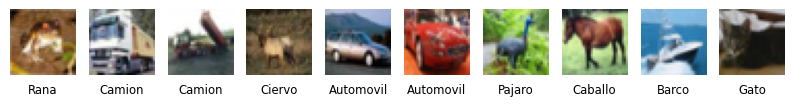

In [5]:
# primero, vemos unas imagenes del set de entrenamiento con sus etiquetas (labels)
figure = plt.figure(figsize=(10, 1))

# configurar tamaño de texto para las graficas
plt.rc('font', size=7)

for i in range(0,10):
  figure.add_subplot(1, 10, i+1)
  img, label = dataset_train[i]

  # img tiene dimensiones [3, 32, 32]
  # Para matplotlib necesitamos [32, 32, 3]
  img = img.permute(1, 2, 0)

  # img tiene dimensiones [1,28,28], squeeze() destruye las dimensiones de tamaño 1
  plt.imshow(img)
  plt.axis('off')
  plt.title(desc[label], y=-0.4)

## Definición del Modelo CNN

Vamos a definir una clase `CNN` que hereda de `nn.Module`. Esta clase contendrá la secuencia de capas que conforman nuestra red neuronal convolucional. Incluiremos capas convolucionales (`nn.Conv2d`), funciones de activación (ReLU), capas de pooling (`nn.MaxPool2d`) para reducir la dimensionalidad y capas completamente conectadas (`nn.Linear`) para la clasificación final.

### Aplicando Regularización: Dropout

El **Dropout** es una técnica de regularización que, durante el entrenamiento, desactiva aleatoriamente un porcentaje de neuronas en las capas de la red. Esto ayuda a prevenir el sobreajuste al hacer que la red sea menos sensible a las activaciones específicas de neuronas individuales y a aprender representaciones más distribuidas y robustas.

Vamos a añadir capas `nn.Dropout` después de las capas ReLU en las partes fully connected de nuestra red.

In [6]:
import torch.nn as nn
import torch.nn.functional as F

class CNN(nn.Module):
    def __init__(self, activation_fn=F.relu):
        super().__init__()
        # Capas convolucionales y de pooling
        self.conv1 = nn.Conv2d(in_channels=3, out_channels=32, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)

        self.conv2 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1)

        self.conv3 = nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3, padding=1)

        # Capas fully connected
        self.fc1 = nn.Linear(128 * 4 * 4, 512)
        self.fc2 = nn.Linear(512, 10)

        # Capas de Dropout añadidas
        self.dropout = nn.Dropout(p=0.5) # Probabilidad de desactivación del 50%

        self.activation_fn = activation_fn # Función de activación seleccionada

    def forward(self, x):
        # Bloque convolucional 1
        x = self.pool(self.activation_fn(self.conv1(x)))
        # Bloque convolucional 2
        x = self.pool(self.activation_fn(self.conv2(x)))
        # Bloque convolucional 3
        x = self.pool(self.activation_fn(self.conv3(x)))

        # Aplanar la salida para las capas fully connected
        x = x.view(-1, 128 * 4 * 4)

        # Capas fully connected con Dropout
        x = self.activation_fn(self.fc1(x))
        x = self.dropout(x) # Aplicar dropout después de la activación
        x = self.fc2(x)
        return x

## Funciones de Entrenamiento y Validación

Primero, definiremos las funciones `train_epoch` y `test_epoch` que manejarán una pasada completa sobre los datos de entrenamiento y prueba, respectivamente. Estas funciones se encargarán de la propagación hacia adelante, el cálculo de la pérdida, la retropropagación y la actualización de los pesos del modelo.

In [7]:
def train_epoch(model, train_loader, criterion, optimizer, device):
    model.train() # Poner el modelo en modo entrenamiento
    running_loss = 0.0
    correct_predictions = 0
    total_samples = 0

    for batch_idx, (data, target) in enumerate(train_loader):
        data, target = data.to(device), target.to(device)

        # Reiniciar los gradientes del optimizador
        optimizer.zero_grad()

        # Propagación hacia adelante
        output = model(data)
        loss = criterion(output, target)

        # Retropropagación y optimización
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * data.size(0)

        # Calcular precisión
        _, predicted = torch.max(output.data, 1)
        total_samples += target.size(0)
        correct_predictions += (predicted == target).sum().item()

    epoch_loss = running_loss / total_samples
    epoch_accuracy = correct_predictions / total_samples
    return epoch_loss, epoch_accuracy

def test_epoch(model, test_loader, criterion, device):
    model.eval() # Poner el modelo en modo evaluación
    test_loss = 0.0
    correct_predictions = 0
    total_samples = 0

    with torch.no_grad(): # Desactivar el cálculo de gradientes
        for data, target in test_loader:
            data, target = data.to(device), target.to(device)
            output = model(data)
            test_loss += criterion(output, target).item() * data.size(0) # sum up batch loss
            _, predicted = torch.max(output.data, 1)
            total_samples += target.size(0)
            correct_predictions += (predicted == target).sum().item()

    test_loss /= total_samples
    test_accuracy = correct_predictions / total_samples
    return test_loss, test_accuracy

### Función de Entrenamiento y Evaluación para Comparación

Definimos una función auxiliar `train_and_evaluate` para facilitar la comparación de diferentes funciones de activación. Esta función creará una nueva instancia del modelo, la entrenará y devolverá las métricas de rendimiento.

In [8]:
import copy

def train_and_evaluate(model_name, activation_fn_param, num_epochs, train_loader, test_loader, device):
    print(f"\n--- Entrenando con {model_name} ---")

    # Crear una nueva instancia del modelo para cada función de activación
    # Asegurarse de que el modelo se reinicia para cada prueba
    model = CNN(activation_fn=activation_fn_param).to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    scheduler = StepLR(optimizer, step_size=5, gamma=0.1)

    model_train_losses = []
    model_train_accuracies = []
    model_test_losses = []
    model_test_accuracies = []

    for epoch in range(1, num_epochs + 1):
        train_loss, train_accuracy = train_epoch(model, train_loader, criterion, optimizer, device)
        test_loss, test_accuracy = test_epoch(model, test_loader, criterion, device)

        scheduler.step()

        model_train_losses.append(train_loss)
        model_train_accuracies.append(train_accuracy)
        model_test_losses.append(test_loss)
        model_test_accuracies.append(test_accuracy)

        print(f"  Epoch {epoch}/{num_epochs}: Train Loss: {train_loss:.4f}, Train Acc: {train_accuracy:.4f}, Test Loss: {test_loss:.4f}, Test Acc: {test_accuracy:.4f}")

    print(f"--- Entrenamiento con {model_name} completado ---")
    return model_train_losses, model_train_accuracies, model_test_losses, model_test_accuracies

## Ejecución del Entrenamiento del Modelo Principal

Ahora instanciamos el modelo principal con la función de activación ReLU por defecto, definimos su función de pérdida, optimizador y el planificador de la tasa de aprendizaje, y ejecutamos el bucle de entrenamiento.

In [9]:
model = CNN().to(device)
# Definir la función de pérdida y el optimizador
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Definir el Learning Rate Scheduler
scheduler = StepLR(optimizer, step_size=5, gamma=0.1) # Reduce el LR por un factor de 0.1 cada 5 épocas

num_epochs = 10 # Puedes ajustar el número de épocas

train_losses = []
train_accuracies = []
test_losses = []
test_accuracies = []

print("Iniciando entrenamiento del modelo principal...")
for epoch in range(1, num_epochs + 1):
    train_loss, train_accuracy = train_epoch(model, train_loader, criterion, optimizer, device)
    test_loss, test_accuracy = test_epoch(model, test_loader, criterion, device)

    scheduler.step() # Actualizar la tasa de aprendizaje después de cada época

    train_losses.append(train_loss)
    train_accuracies.append(train_accuracy)
    test_losses.append(test_loss)
    test_accuracies.append(test_accuracy)

    print(f"Epoch {epoch}/{num_epochs}:\n"\
          f"  Train Loss: {train_loss:.4f}, Train Acc: {train_accuracy:.4f}\n"\
          f"  Test Loss: {test_loss:.4f}, Test Acc: {test_accuracy:.4f}")

print("Entrenamiento del modelo principal completado.")

Iniciando entrenamiento del modelo principal...
Epoch 1/10:
  Train Loss: 1.5426, Train Acc: 0.4313
  Test Loss: 1.2015, Test Acc: 0.5675
Epoch 2/10:
  Train Loss: 1.1213, Train Acc: 0.6014
  Test Loss: 0.9878, Test Acc: 0.6550
Epoch 3/10:
  Train Loss: 0.9508, Train Acc: 0.6668
  Test Loss: 0.9071, Test Acc: 0.6839
Epoch 4/10:
  Train Loss: 0.8393, Train Acc: 0.7048
  Test Loss: 0.8403, Test Acc: 0.7080
Epoch 5/10:
  Train Loss: 0.7566, Train Acc: 0.7343
  Test Loss: 0.7920, Test Acc: 0.7229
Epoch 6/10:
  Train Loss: 0.6093, Train Acc: 0.7878
  Test Loss: 0.7286, Test Acc: 0.7479
Epoch 7/10:
  Train Loss: 0.5756, Train Acc: 0.8011
  Test Loss: 0.7214, Test Acc: 0.7534
Epoch 8/10:
  Train Loss: 0.5568, Train Acc: 0.8047
  Test Loss: 0.7204, Test Acc: 0.7553
Epoch 9/10:
  Train Loss: 0.5404, Train Acc: 0.8110
  Test Loss: 0.7171, Test Acc: 0.7563
Epoch 10/10:
  Train Loss: 0.5263, Train Acc: 0.8162
  Test Loss: 0.7122, Test Acc: 0.7604
Entrenamiento del modelo principal completado.


## Presentación de Resultados del Modelo Principal

Para visualizar el progreso del entrenamiento, graficaremos la pérdida y la precisión en los conjuntos de entrenamiento y prueba a lo largo de las épocas para el modelo principal.

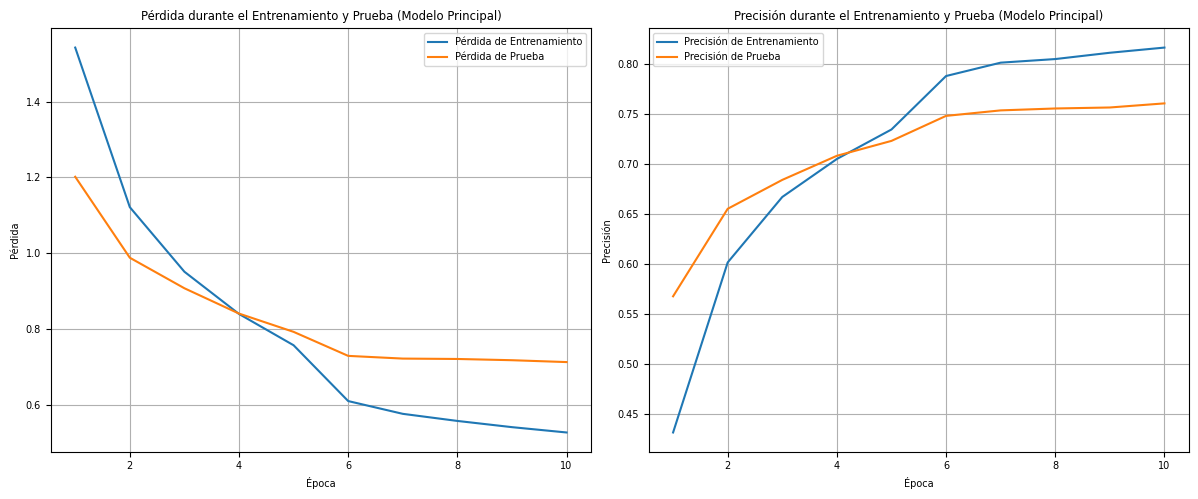

In [10]:
# Graficar la pérdida
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(range(1, num_epochs + 1), train_losses, label='Pérdida de Entrenamiento')
plt.plot(range(1, num_epochs + 1), test_losses, label='Pérdida de Prueba')
plt.xlabel('Época')
plt.ylabel('Pérdida')
plt.title('Pérdida durante el Entrenamiento y Prueba (Modelo Principal)')
plt.legend()
plt.grid(True)

# Graficar la precisión
plt.subplot(1, 2, 2)
plt.plot(range(1, num_epochs + 1), train_accuracies, label='Precisión de Entrenamiento')
plt.plot(range(1, num_epochs + 1), test_accuracies, label='Precisión de Prueba')
plt.xlabel('Época')
plt.ylabel('Precisión')
plt.title('Precisión durante el Entrenamiento y Prueba (Modelo Principal)')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

### Evaluación Final del Modelo Principal

También podemos mostrar algunas predicciones del modelo principal en el conjunto de prueba para tener una idea cualitativa de su rendimiento.

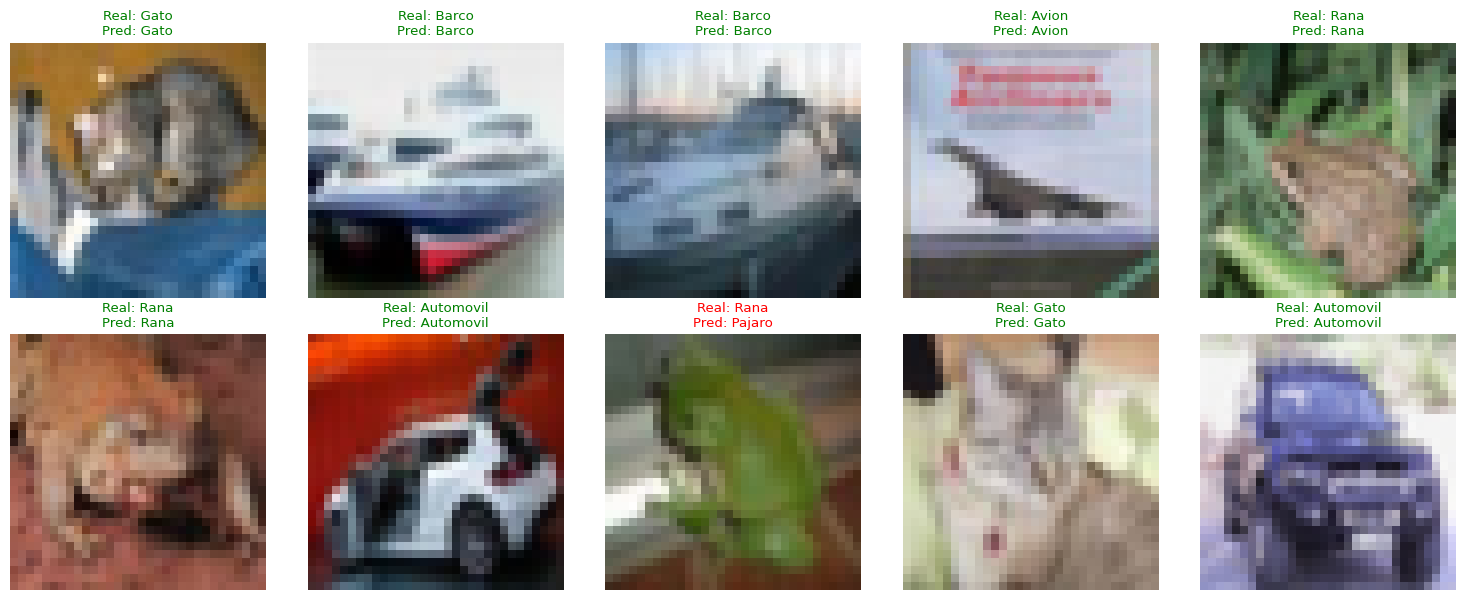

In [11]:
model.eval()

# Obtener un batch de imágenes de prueba
dataiter = iter(test_loader)
images, labels = next(dataiter)

# Realizar predicciones
outputs = model(images.to(device))
_, predicted = torch.max(outputs.cpu().data, 1)

# Mostrar imágenes y predicciones
fig = plt.figure(figsize=(15, 6))
plt.rc('font', size=8)
for i in range(10):
    ax = fig.add_subplot(2, 5, i+1)
    # img tiene dimensiones [3, 32, 32], permute para matplotlib [32, 32, 3]
    img = images[i].permute(1, 2, 0)
    ax.imshow(img)
    ax.set_title(f"Real: {desc[labels[i]]}\nPred: {desc[predicted[i]]}", color=('green' if predicted[i] == labels[i] else 'red'))
    ax.axis('off')
plt.tight_layout()
plt.show()

## Comparación de Funciones de Activación

Ahora que la clase `CNN` es más flexible, podemos comparar el impacto de diferentes funciones de activación en el rendimiento del modelo. Entrenaremos tres modelos separados utilizando ReLU, LeakyReLU y ELU, y luego visualizaremos sus curvas de entrenamiento para identificar cuál funciona mejor para esta tarea.

In [ ]:
num_epochs_compare = 10 # Define el número de épocas para la comparación

results = {}

# Entrenar con ReLU
relu_train_losses, relu_train_accuracies, relu_test_losses, relu_test_accuracies = \
    train_and_evaluate("ReLU", F.relu, num_epochs_compare, train_loader, test_loader, device)
results["ReLU"] = {
    "train_losses": relu_train_losses,
    "train_accuracies": relu_train_accuracies,
    "test_losses": relu_test_losses,
    "test_accuracies": relu_test_accuracies
}

# Entrenar con LeakyReLU
leaky_relu_train_losses, leaky_relu_train_accuracies, leaky_relu_test_losses, leaky_relu_test_accuracies = \
    train_and_evaluate("LeakyReLU", F.leaky_relu, num_epochs_compare, train_loader, test_loader, device)
results["LeakyReLU"] = {
    "train_losses": leaky_relu_train_losses,
    "train_accuracies": leaky_relu_train_accuracies,
    "test_losses": leaky_relu_test_losses,
    "test_accuracies": leaky_relu_test_accuracies
}

# Entrenar con ELU
elu_train_losses, elu_train_accuracies, elu_test_losses, elu_test_accuracies = \
    train_and_evaluate("ELU", F.elu, num_epochs_compare, train_loader, test_loader, device)
results["ELU"] = {
    "train_losses": elu_train_losses,
    "train_accuracies": elu_train_accuracies,
    "test_losses": elu_test_losses,
    "test_accuracies": elu_test_accuracies
}


--- Entrenando con ReLU ---
  Epoch 1/10: Train Loss: 1.5579, Train Acc: 0.4317, Test Loss: 1.2020, Test Acc: 0.5726
  Epoch 2/10: Train Loss: 1.1463, Train Acc: 0.5928, Test Loss: 1.0046, Test Acc: 0.6458
  Epoch 3/10: Train Loss: 0.9652, Train Acc: 0.6610, Test Loss: 0.8839, Test Acc: 0.6852
  Epoch 4/10: Train Loss: 0.8440, Train Acc: 0.7046, Test Loss: 0.8295, Test Acc: 0.7103
  Epoch 5/10: Train Loss: 0.7557, Train Acc: 0.7349, Test Loss: 0.7996, Test Acc: 0.7236
  Epoch 6/10: Train Loss: 0.6055, Train Acc: 0.7882, Test Loss: 0.7222, Test Acc: 0.7516
  Epoch 7/10: Train Loss: 0.5734, Train Acc: 0.7995, Test Loss: 0.7174, Test Acc: 0.7529
  Epoch 8/10: Train Loss: 0.5561, Train Acc: 0.8069, Test Loss: 0.7080, Test Acc: 0.7581
  Epoch 9/10: Train Loss: 0.5398, Train Acc: 0.8114, Test Loss: 0.7103, Test Acc: 0.7568
  Epoch 10/10: Train Loss: 0.5252, Train Acc: 0.8175, Test Loss: 0.7088, Test Acc: 0.7576
--- Entrenamiento con ReLU completado ---

--- Entrenando con LeakyReLU ---


### Graficar los Resultados de la Comparación de Funciones de Activación

Finalmente, vamos a graficar los resultados de la pérdida y precisión de prueba para comparar el rendimiento de cada función de activación.

In [ ]:
plt.figure(figsize=(15, 6))

# Graficar Pérdida de Entrenamiento
plt.subplot(1, 2, 1)
for name, data in results.items():
    plt.plot(range(1, num_epochs_compare + 1), data["test_losses"], label=f'Pérdida de Prueba {name}')
plt.xlabel('Época')
plt.ylabel('Pérdida')
plt.title('Comparación de Pérdida de Prueba por Función de Activación')
plt.legend()
plt.grid(True)

# Graficar Precisión de Entrenamiento
plt.subplot(1, 2, 2)
for name, data in results.items():
    plt.plot(range(1, num_epochs_compare + 1), data["test_accuracies"], label=f'Precisión de Prueba {name}')
plt.xlabel('Época')
plt.ylabel('Precisión')
plt.title('Comparación de Precisión de Prueba por Función de Activación')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

Con esta modificación, el modelo `CNN` ahora incluye Dropout. Para ver el efecto, necesitarás:

1.  **Ejecutar la celda de arriba** para que la nueva definición de la clase `CNN` sea cargada.
2.  **Re-ejecutar la celda donde se instancia el modelo (`model = CNN().to(device)`) y se definen el criterio y el optimizador.**
3.  **Re-ejecutar el bucle de entrenamiento completo y la presentación de resultados.**

Esto te permitirá observar cómo el Dropout afecta la pérdida y la precisión de entrenamiento y prueba.

In [ ]:
# Comparación de Funciones de Activación

#Ahora que la clase `CNN` es más flexible, podemos comparar el impacto de diferentes funciones de activación en el rendimiento del modelo. Entrenaremos tres modelos separados utilizando ReLU, LeakyReLU y ELU, y luego visualizaremos sus curvas de entrenamiento para identificar cuál funciona mejor para esta tarea.

In [ ]:
import copy

def train_and_evaluate(model_name, activation_fn_param, num_epochs, train_loader, test_loader, device):
    print(f"\n--- Entrenando con {model_name} ---")

    # Crear una nueva instancia del modelo para cada función de activación
    # Asegurarse de que el modelo se reinicia para cada prueba
    model = CNN(activation_fn=activation_fn_param).to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    scheduler = StepLR(optimizer, step_size=5, gamma=0.1)

    model_train_losses = []
    model_train_accuracies = []
    model_test_losses = []
    model_test_accuracies = []

    for epoch in range(1, num_epochs + 1):
        train_loss, train_accuracy = train_epoch(model, train_loader, criterion, optimizer, device)
        test_loss, test_accuracy = test_epoch(model, test_loader, criterion, device)

        scheduler.step()

        model_train_losses.append(train_loss)
        model_train_accuracies.append(train_accuracy)
        model_test_losses.append(test_loss)
        model_test_accuracies.append(test_accuracy)

        print(f"  Epoch {epoch}/{num_epochs}: Train Loss: {train_loss:.4f}, Train Acc: {train_accuracy:.4f}, Test Loss: {test_loss:.4f}, Test Acc: {test_accuracy:.4f}")

    print(f"--- Entrenamiento con {model_name} completado ---")
    return model_train_losses, model_train_accuracies, model_test_losses, model_test_accuracies

Ahora, ejecutaremos esta función para cada una de las funciones de activación que queremos comparar.

In [ ]:
num_epochs_compare = 10 # Define el número de épocas para la comparación

results = {}

# Entrenar con ReLU
relu_train_losses, relu_train_accuracies, relu_test_losses, relu_test_accuracies = \
    train_and_evaluate("ReLU", F.relu, num_epochs_compare, train_loader, test_loader, device)
results["ReLU"] = {
    "train_losses": relu_train_losses,
    "train_accuracies": relu_train_accuracies,
    "test_losses": relu_test_losses,
    "test_accuracies": relu_test_accuracies
}

# Entrenar con LeakyReLU
leaky_relu_train_losses, leaky_relu_train_accuracies, leaky_relu_test_losses, leaky_relu_test_accuracies = \
    train_and_evaluate("LeakyReLU", F.leaky_relu, num_epochs_compare, train_loader, test_loader, device)
results["LeakyReLU"] = {
    "train_losses": leaky_relu_train_losses,
    "train_accuracies": leaky_relu_train_accuracies,
    "test_losses": leaky_relu_test_losses,
    "test_accuracies": leaky_relu_test_accuracies
}

# Entrenar con ELU
elu_train_losses, elu_train_accuracies, elu_test_losses, elu_test_accuracies = \
    train_and_evaluate("ELU", F.elu, num_epochs_compare, train_loader, test_loader, device)
results["ELU"] = {
    "train_losses": elu_train_losses,
    "train_accuracies": elu_train_accuracies,
    "test_losses": elu_test_losses,
    "test_accuracies": elu_test_accuracies
}

Finalmente, vamos a graficar los resultados para comparar el rendimiento de cada función de activación.

In [ ]:
plt.figure(figsize=(15, 6))

# Graficar Pérdida de Entrenamiento
plt.subplot(1, 2, 1)
for name, data in results.items():
    plt.plot(range(1, num_epochs_compare + 1), data["test_losses"], label=f'Pérdida de Prueba {name}')
plt.xlabel('Época')
plt.ylabel('Pérdida')
plt.title('Comparación de Pérdida de Prueba por Función de Activación')
plt.legend()
plt.grid(True)

# Graficar Precisión de Entrenamiento
plt.subplot(1, 2, 2)
for name, data in results.items():
    plt.plot(range(1, num_epochs_compare + 1), data["test_accuracies"], label=f'Precisión de Prueba {name}')
plt.xlabel('Época')
plt.ylabel('Precisión')
plt.title('Comparación de Precisión de Prueba por Función de Activación')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

## Funciones de Entrenamiento y Validación

Primero, definiremos la función de pérdida (Cross-Entropy Loss para clasificación) y un optimizador (Adam en este caso) para actualizar los pesos del modelo.

In [ ]:
model = CNN().to(device)
# Definir la función de pérdida y el optimizador
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Definir el Learning Rate Scheduler
scheduler = StepLR(optimizer, step_size=5, gamma=0.1) # Reduce el LR por un factor de 0.1 cada 5 épocas

Ahora, crearemos las funciones `train_epoch` y `test_epoch` que manejarán una pasada completa sobre los datos de entrenamiento y prueba, respectivamente. Estas funciones se encargarán de la propagación hacia adelante, el cálculo de la pérdida, la retropropagación y la actualización de los pesos del modelo.

In [ ]:
def train_epoch(model, train_loader, criterion, optimizer, device):
    model.train() # Poner el modelo en modo entrenamiento
    running_loss = 0.0
    correct_predictions = 0
    total_samples = 0

    for batch_idx, (data, target) in enumerate(train_loader):
        data, target = data.to(device), target.to(device)

        # Reiniciar los gradientes del optimizador
        optimizer.zero_grad()

        # Propagación hacia adelante
        output = model(data)
        loss = criterion(output, target)

        # Retropropagación y optimización
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * data.size(0)

        # Calcular precisión
        _, predicted = torch.max(output.data, 1)
        total_samples += target.size(0)
        correct_predictions += (predicted == target).sum().item()

    epoch_loss = running_loss / total_samples
    epoch_accuracy = correct_predictions / total_samples
    return epoch_loss, epoch_accuracy

def test_epoch(model, test_loader, criterion, device):
    model.eval() # Poner el modelo en modo evaluación
    test_loss = 0.0
    correct_predictions = 0
    total_samples = 0

    with torch.no_grad(): # Desactivar el cálculo de gradientes
        for data, target in test_loader:
            data, target = data.to(device), target.to(device)
            output = model(data)
            test_loss += criterion(output, target).item() * data.size(0) # sum up batch loss
            _, predicted = torch.max(output.data, 1)
            total_samples += target.size(0)
            correct_predictions += (predicted == target).sum().item()

    test_loss /= total_samples
    test_accuracy = correct_predictions / total_samples
    return test_loss, test_accuracy

## Ejecución del Entrenamiento

Ahora ejecutaremos el bucle de entrenamiento principal durante un número determinado de épocas. Almacenaremos la pérdida y la precisión tanto para el conjunto de entrenamiento como para el de prueba en cada época para poder visualizarlas más tarde.

In [ ]:
num_epochs = 10 # Puedes ajustar el número de épocas

train_losses = []
train_accuracies = []
test_losses = []
test_accuracies = []

print("Iniciando entrenamiento...")
for epoch in range(1, num_epochs + 1):
    train_loss, train_accuracy = train_epoch(model, train_loader, criterion, optimizer, device)
    test_loss, test_accuracy = test_epoch(model, test_loader, criterion, device)

    scheduler.step() # Actualizar la tasa de aprendizaje después de cada época

    train_losses.append(train_loss)
    train_accuracies.append(train_accuracy)
    test_losses.append(test_loss)
    test_accuracies.append(test_accuracy)

    print(f"Epoch {epoch}/{num_epochs}:\n"\
          f"  Train Loss: {train_loss:.4f}, Train Acc: {train_accuracy:.4f}\n"\
          f"  Test Loss: {test_loss:.4f}, Test Acc: {test_accuracy:.4f}")

print("Entrenamiento completado.")

## Presentación de Resultados

Para visualizar el progreso del entrenamiento, graficaremos la pérdida y la precisión en los conjuntos de entrenamiento y prueba a lo largo de las épocas.

In [ ]:
# Graficar la pérdida
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(range(1, num_epochs + 1), train_losses, label='Pérdida de Entrenamiento')
plt.plot(range(1, num_epochs + 1), test_losses, label='Pérdida de Prueba')
plt.xlabel('Época')
plt.ylabel('Pérdida')
plt.title('Pérdida durante el Entrenamiento y Prueba')
plt.legend()
plt.grid(True)

# Graficar la precisión
plt.subplot(1, 2, 2)
plt.plot(range(1, num_epochs + 1), train_accuracies, label='Precisión de Entrenamiento')
plt.plot(range(1, num_epochs + 1), test_accuracies, label='Precisión de Prueba')
plt.xlabel('Época')
plt.ylabel('Precisión')
plt.title('Precisión durante el Entrenamiento y Prueba')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

### Evaluación Final del Modelo

También podemos mostrar algunas predicciones del modelo en el conjunto de prueba para tener una idea cualitativa de su rendimiento.

In [ ]:
model.eval()

# Obtener un batch de imágenes de prueba
dataiter = iter(test_loader)
images, labels = next(dataiter)

# Realizar predicciones
outputs = model(images.to(device))
_, predicted = torch.max(outputs.cpu().data, 1)

# Mostrar imágenes y predicciones
fig = plt.figure(figsize=(15, 6))
plt.rc('font', size=8)
for i in range(10):
    ax = fig.add_subplot(2, 5, i+1)
    # img tiene dimensiones [3, 32, 32], permute para matplotlib [32, 32, 3]
    img = images[i].permute(1, 2, 0)
    ax.imshow(img)
    ax.set_title(f"Real: {desc[labels[i]]}\nPred: {desc[predicted[i]]}", color=('green' if predicted[i] == labels[i] else 'red'))
    ax.axis('off')
plt.tight_layout()
plt.show()